In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import datetime

# Testing set analysis

In [2]:
data_path = '../../data/01_processed/pan21-authorship-verification-test.jsonl'

data_file_size = os.path.getsize(data_path)
data = []

with open(data_path, 'r') as f:
    with tqdm(total=data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(data)} items.")

Loading data: 100%|██████████| 873M/873M [00:06<00:00, 137MB/s]  


Successfully loaded 19999 items.


Load the data into the pandas dataframe

In [3]:
data_df = pd.DataFrame(data)
data_df.drop(columns=['fandoms'], inplace=True)
print(data_df.head(10))

                                     id  \
0  c28e8b03-c02a-5184-b58a-12dd28b8ca74   
1  b9326101-6352-56dd-9d1b-1f41466897b7   
2  e2ac4453-bf54-53f2-bf68-6caae6aacded   
3  a5e9a289-0999-5764-b597-dc1bf8c21ede   
4  cb4054b1-d422-58d6-a137-dcfc70100df6   
5  bc9a7911-eabd-5101-8533-dd35aacef865   
6  8c7c1a34-a42a-5b91-ab8f-4fd1a6a5d9d7   
7  223106aa-03eb-5b54-b741-bbc0ceed0f86   
8  dae55351-369d-5d80-aa55-3dfc9e322a5a   
9  734150a2-3e67-5c72-bba8-e41d50427450   

                                                pair  
0  [talk because they hadn"t been exposed to comm...  
1  [Zazuki nodded his head and got to his feet, k...  
2  ["Oh we did lots of special things. On Christm...  
3  ["Hey now, at least Shido brings home some mon...  
4  [It was a mere five minutes" walk from third y...  
5  [When Mello thought that his fingers are well ...  
6  [Aeian"s eyes were blue, so blue, and her touc...  
7  ["Don"t mock me with that no nonsense tone of ...  
8  [into the dirt as her hands 

Load the testing set labels

In [4]:
data_truth_path = '../../data/01_processed/pan21-authorship-verification-test-truth.jsonl'

data_truth_file_size = os.path.getsize(data_truth_path)
data_truth = []

with open(data_truth_path, 'r') as f:
    with tqdm(total=data_truth_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            data_truth.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(data_truth)} items.")

Loading data: 100%|██████████| 1.91M/1.91M [00:00<00:00, 12.2MB/s]


Successfully loaded 19999 items.


Load the data into pandas dataframe

In [5]:
data_truth_df = pd.DataFrame(data_truth)
data_truth_df.drop(columns=['authors'], inplace=True)
print(data_truth_df.head())

                                     id   same
0  c28e8b03-c02a-5184-b58a-12dd28b8ca74   True
1  b9326101-6352-56dd-9d1b-1f41466897b7   True
2  e2ac4453-bf54-53f2-bf68-6caae6aacded  False
3  a5e9a289-0999-5764-b597-dc1bf8c21ede   True
4  cb4054b1-d422-58d6-a137-dcfc70100df6   True


Combine the dataframes for evaluation

In [6]:
data_full_df = pd.merge(data_df, data_truth_df, on='id')
data_full_reduced_df =  data_full_df.head(200)
print(data_full_df.head())

                                     id  \
0  c28e8b03-c02a-5184-b58a-12dd28b8ca74   
1  b9326101-6352-56dd-9d1b-1f41466897b7   
2  e2ac4453-bf54-53f2-bf68-6caae6aacded   
3  a5e9a289-0999-5764-b597-dc1bf8c21ede   
4  cb4054b1-d422-58d6-a137-dcfc70100df6   

                                                pair   same  
0  [talk because they hadn"t been exposed to comm...   True  
1  [Zazuki nodded his head and got to his feet, k...   True  
2  ["Oh we did lots of special things. On Christm...  False  
3  ["Hey now, at least Shido brings home some mon...   True  
4  [It was a mere five minutes" walk from third y...   True  


Check for duplicates of pairs of text

In [7]:
pair_tuples = data_full_df['pair'].apply(frozenset)
any_duplicates = pair_tuples.duplicated().any()
any_duplicates

False

check for duplicates of texts

In [8]:
all_texts = data_df['pair'].explode()
text_counts = all_texts.value_counts()
text_counts.values

array([5, 5, 5, ..., 1, 1, 1])

The counts of each category for both datasets

In [9]:
label_counts = data_full_df["same"].value_counts()
label_counts

same
True     10000
False     9999
Name: count, dtype: int64

Longest text

In [10]:
all_texts_list = list(all_texts.values)
all_texts_list.sort(reverse=True, key=len)
len(all_texts_list[0])

458751

Shortest text

In [11]:
len(all_texts_list[-1])

20651

Median text length

In [12]:
all_texts_length_list = [len(text) for text in all_texts_list]
median_texts_length = np.median(all_texts_length_list)
median_texts_length

21291.0

Average text length

In [13]:
average_texts_length = np.average(all_texts_length_list)
average_texts_length 

21431.237461873094

create text length graph

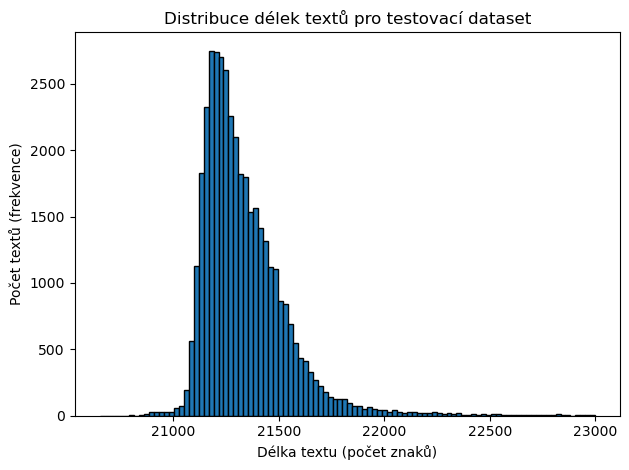

In [15]:
limited_lengths_list = [length for length in all_texts_length_list if length > 15000 and length < 23000]
plt.hist(limited_lengths_list, bins=100, edgecolor='black')

plt.title('Distribuce délek textů pro testovací dataset')
plt.xlabel('Délka textu (počet znaků)')
plt.ylabel('Počet textů (frekvence)')

plt.tight_layout()

today = datetime.date.today()
date_string = today.strftime("%Y%m%d%m")

plt.savefig(f'../../data/04_reporting/{date_string}_JP-test_dataset_text_length_histogram.png')
plt.show()